# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Parental Genetics Child Dataset](https://www.kaggle.com/datasets/aliyasaly1231/parental-genetics-and-child-trait-prediction-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

/kaggle/input/datasets/aliyasaly1231/parental-genetics-and-child-trait-prediction-dataset/parental_genetics_child_traits.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('parental_genetics_child_traits.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
0,FAM00001,48,40,163.9,168.6,O+,B+,Green,Brown,Black,Brown,Olive,Light,Multiple,Female,161.9,B+,High
1,FAM00002,34,24,185.5,152.2,A+,A+,Brown,Blue,Black,Brown,Olive,Medium,Hypertension,Female,164.0,A+,Moderate
2,FAM00003,27,36,178.8,158.0,A+,A+,Blue,Blue,Brown,Black,Fair,Olive,Multiple,Female,162.2,A+,High
3,FAM00004,40,26,161.0,157.8,O+,AB-,Brown,Brown,Black,Black,Dark,Dark,Diabetes,Male,161.7,A-,Moderate
4,FAM00005,38,35,175.7,160.7,A-,O+,Hazel,Brown,Brown,Black,Medium,Fair,Asthma,Male,171.7,A+,Moderate


## last Five row

In [4]:
df.tail()

,Family_ID,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Father_Blood_Group,Mother_Blood_Group,Father_Eye_Color,Mother_Eye_Color,Father_Hair_Color,Mother_Hair_Color,Father_Skin_Tone,Mother_Skin_Tone,Family_Disease_History,Child_Gender,Predicted_Child_Height_cm,Predicted_Child_Blood_Group,Predicted_Health_Risk
6995,FAM06996,38,46,179.3,151.2,A+,AB+,Green,Green,Black,Brown,Medium,Medium,NaN,Female,155.5,AB+,Moderate
6996,FAM06997,30,22,172.5,159.1,A+,B+,Green,Brown,Black,Brown,Light,Dark,Hypertension,Male,166.7,AB+,Moderate
6997,FAM06998,22,31,160.9,154.2,B+,B-,Brown,Hazel,Black,Brown,Dark,Dark,Diabetes,Female,153.6,B+,Moderate
6998,FAM06999,42,19,174.1,154.0,B-,B+,Brown,Blue,Blonde,Black,Light,Dark,Hypertension,Male,167.8,B-,Moderate
6999,FAM07000,26,40,174.9,168.4,A+,B+,Green,Brown,Brown,Black,Olive,Light,Hypertension,Male,177.0,AB+,Moderate


## Shape of our dataset

In [5]:
df.shape

(7000, 18)

## List out all columns

In [6]:
df.columns

Index(['Family_ID', 'Father_Age', 'Mother_Age', 'Father_Height_cm',
       'Mother_Height_cm', 'Father_Blood_Group', 'Mother_Blood_Group',
       'Father_Eye_Color', 'Mother_Eye_Color', 'Father_Hair_Color',
       'Mother_Hair_Color', 'Father_Skin_Tone', 'Mother_Skin_Tone',
       'Family_Disease_History', 'Child_Gender', 'Predicted_Child_Height_cm',
       'Predicted_Child_Blood_Group', 'Predicted_Health_Risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Family_ID                       object
Father_Age                       int64
Mother_Age                       int64
Father_Height_cm               float64
Mother_Height_cm               float64
Father_Blood_Group              object
Mother_Blood_Group              object
Father_Eye_Color                object
Mother_Eye_Color                object
Father_Hair_Color               object
Mother_Hair_Color               object
Father_Skin_Tone                object
Mother_Skin_Tone                object
Family_Disease_History          object
Child_Gender                    object
Predicted_Child_Height_cm      float64
Predicted_Child_Blood_Group     object
Predicted_Health_Risk           object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Family_ID                    7000 non-null   object 
 1   Father_Age                   7000 non-null   int64  
 2   Mother_Age                   7000 non-null   int64  
 3   Father_Height_cm             7000 non-null   float64
 4   Mother_Height_cm             7000 non-null   float64
 5   Father_Blood_Group           7000 non-null   object 
 6   Mother_Blood_Group           7000 non-null   object 
 7   Father_Eye_Color             7000 non-null   object 
 8   Mother_Eye_Color             7000 non-null   object 
 9   Father_Hair_Color            7000 non-null   object 
 10  Mother_Hair_Color            7000 non-null   object 
 11  Father_Skin_Tone             7000 non-null   object 
 12  Mother_Skin_Tone             7000 non-null   object 
 13  Family_Disease_His

## Check Null Value

In [9]:
df.isnull().sum()

Family_ID                         0
Father_Age                        0
Mother_Age                        0
Father_Height_cm                  0
Mother_Height_cm                  0
Father_Blood_Group                0
Mother_Blood_Group                0
Father_Eye_Color                  0
Mother_Eye_Color                  0
Father_Hair_Color                 0
Mother_Hair_Color                 0
Father_Skin_Tone                  0
Mother_Skin_Tone                  0
Family_Disease_History         2461
Child_Gender                      0
Predicted_Child_Height_cm         0
Predicted_Child_Blood_Group       0
Predicted_Health_Risk             0
dtype: int64

## Drop Family Disease History Features

In [10]:
df.drop(columns='Family_Disease_History', inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Father_Age,Mother_Age,Father_Height_cm,Mother_Height_cm,Predicted_Child_Height_cm
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,37.650286,34.035857,173.970257,161.084257,167.595814
std,10.323333,9.447972,6.922160,5.971471,8.816473
min,20.000000,18.000000,155.000000,145.000000,140.600000
25%,29.000000,26.000000,169.200000,157.000000,161.100000
50%,38.000000,34.000000,174.000000,161.100000,167.700000
75%,47.000000,42.000000,178.700000,165.200000,174.200000
max,55.000000,50.000000,197.900000,185.000000,198.500000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

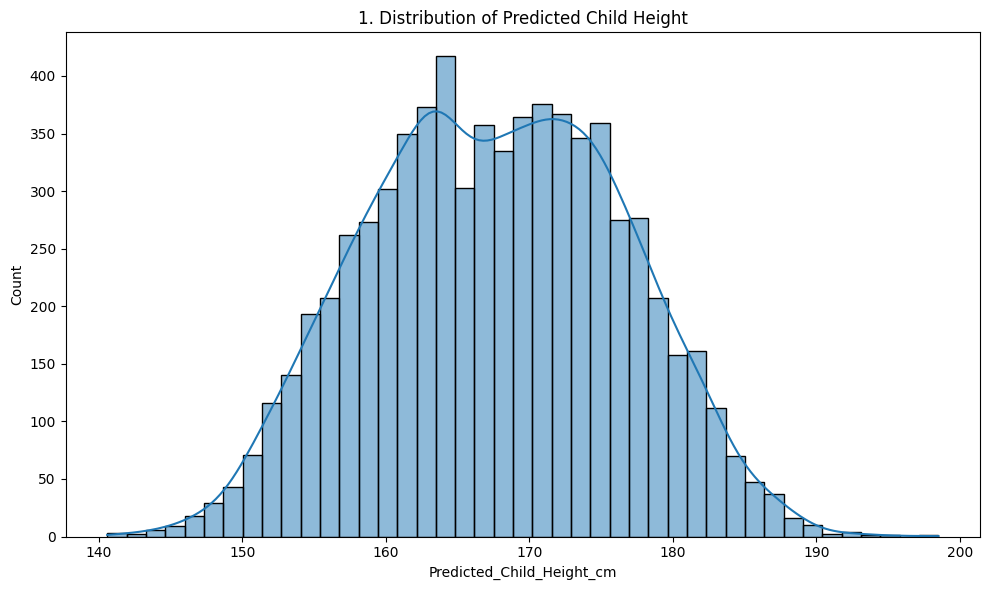

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Predicted_Child_Height_cm'], kde=True)
plt.title(f'{plot_no}. Distribution of Predicted Child Height')
show_fig()
plot_no += 1

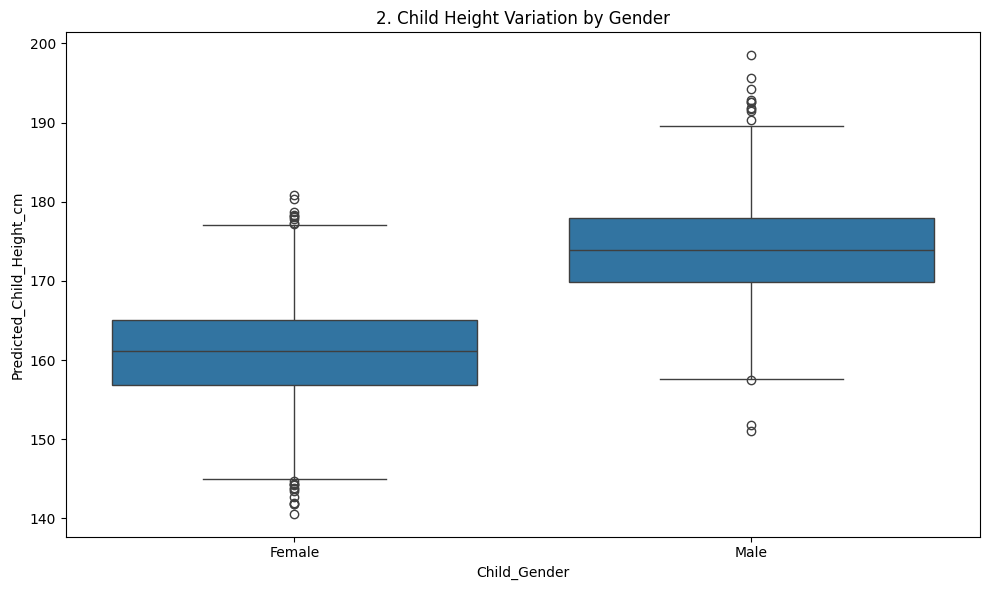

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Child_Gender', y='Predicted_Child_Height_cm')
plt.title(f'{plot_no}. Child Height Variation by Gender')
show_fig()
plot_no += 1

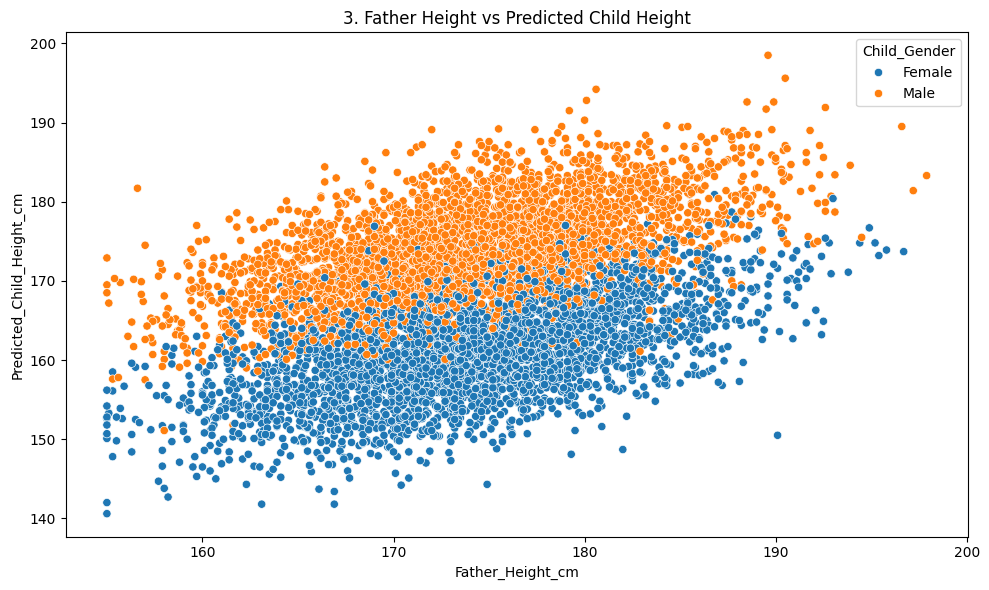

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Father_Height_cm', y='Predicted_Child_Height_cm', hue='Child_Gender')
plt.title(f'{plot_no}. Father Height vs Predicted Child Height')
show_fig()
plot_no += 1

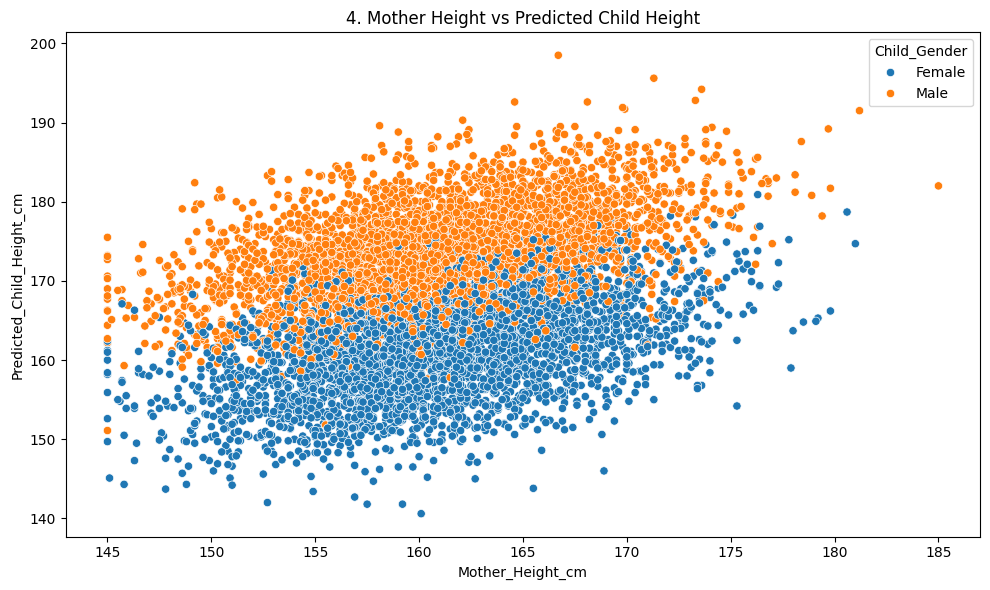

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Mother_Height_cm', y='Predicted_Child_Height_cm', hue='Child_Gender')
plt.title(f'{plot_no}. Mother Height vs Predicted Child Height')
show_fig()
plot_no += 1

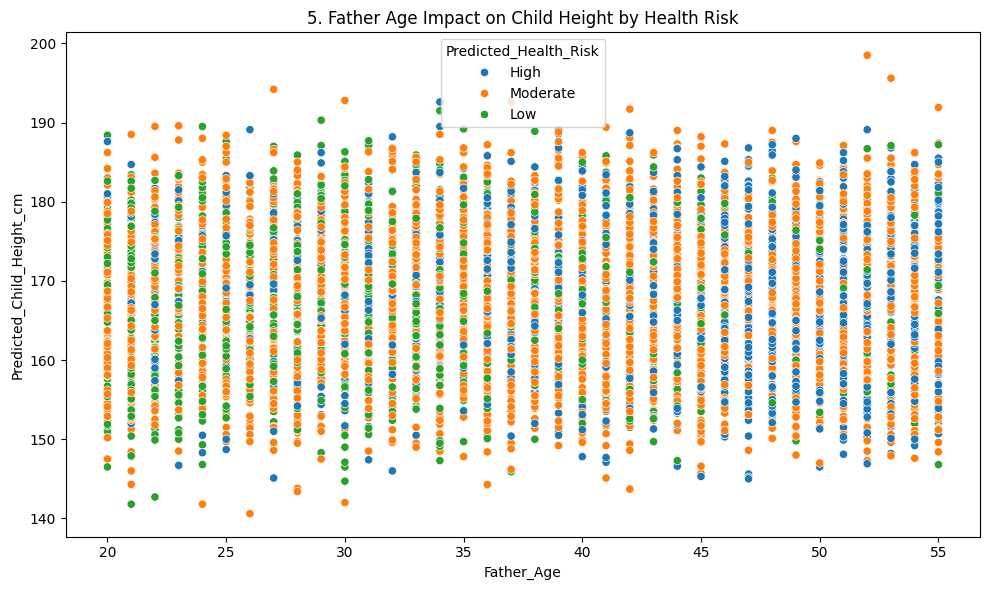

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Father_Age', y='Predicted_Child_Height_cm', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Father Age Impact on Child Height by Health Risk')
show_fig()
plot_no += 1

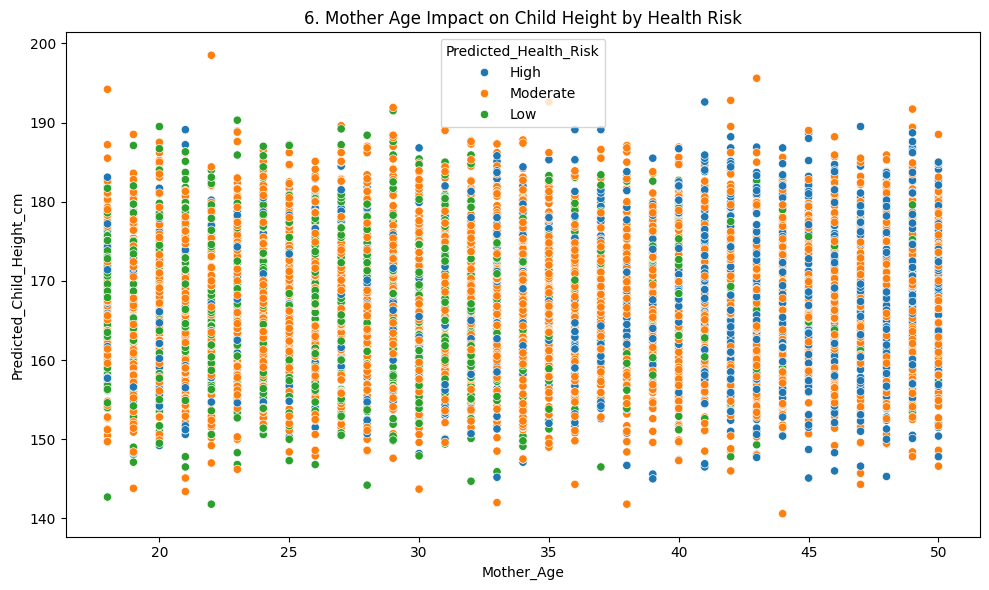

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Mother_Age', y='Predicted_Child_Height_cm', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Mother Age Impact on Child Height by Health Risk')
show_fig()
plot_no += 1

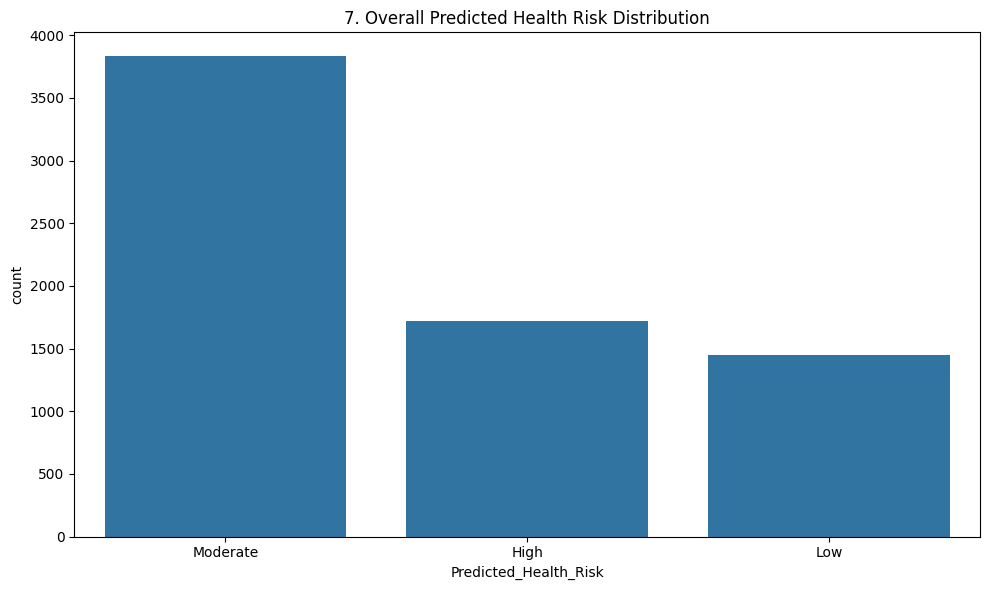

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Predicted_Health_Risk', order=df['Predicted_Health_Risk'].value_counts().index)
plt.title(f'{plot_no}. Overall Predicted Health Risk Distribution')
show_fig()
plot_no += 1

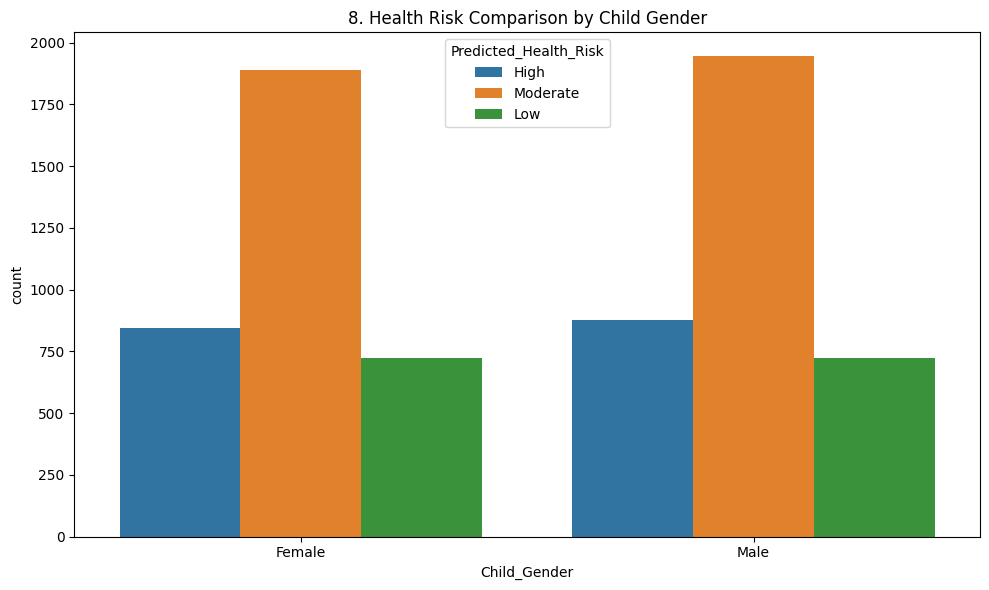

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Child_Gender', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Health Risk Comparison by Child Gender')
show_fig()
plot_no += 1

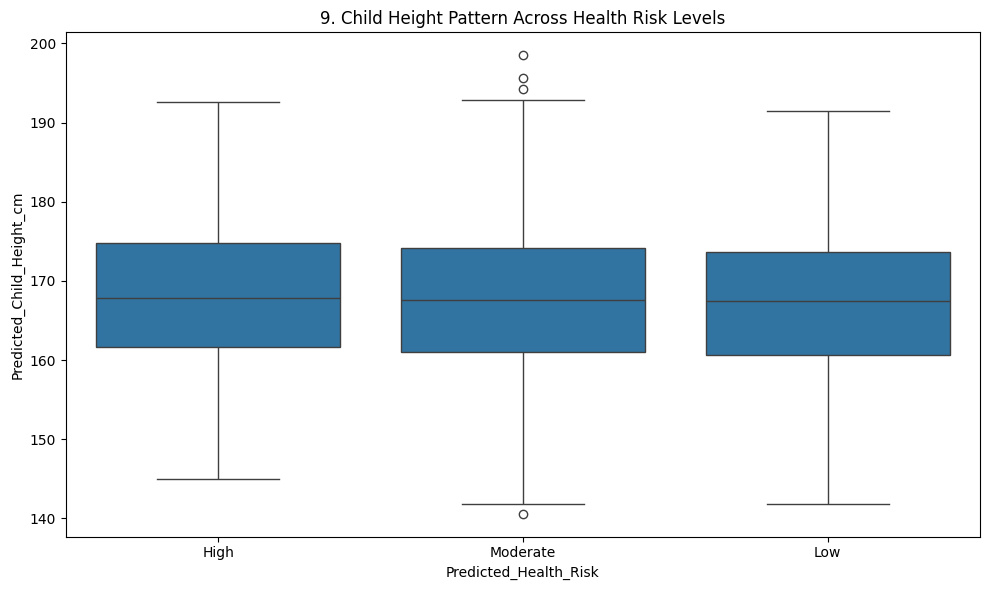

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Predicted_Health_Risk', y='Predicted_Child_Height_cm')
plt.title(f'{plot_no}. Child Height Pattern Across Health Risk Levels')
show_fig()
plot_no += 1

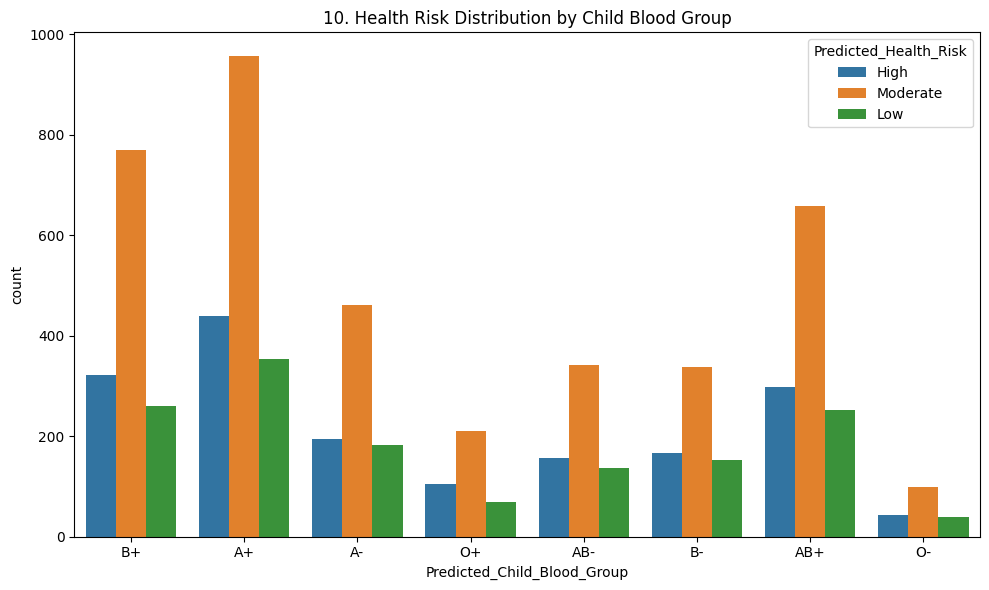

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Predicted_Child_Blood_Group', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Health Risk Distribution by Child Blood Group')
show_fig()
plot_no += 1

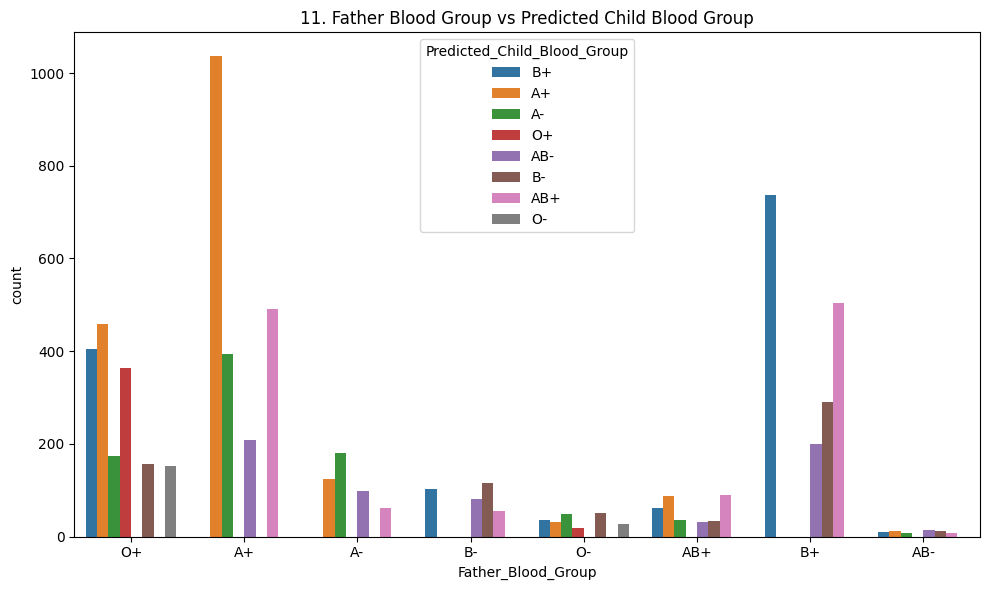

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Father_Blood_Group', hue='Predicted_Child_Blood_Group')
plt.title(f'{plot_no}. Father Blood Group vs Predicted Child Blood Group')
show_fig()
plot_no += 1

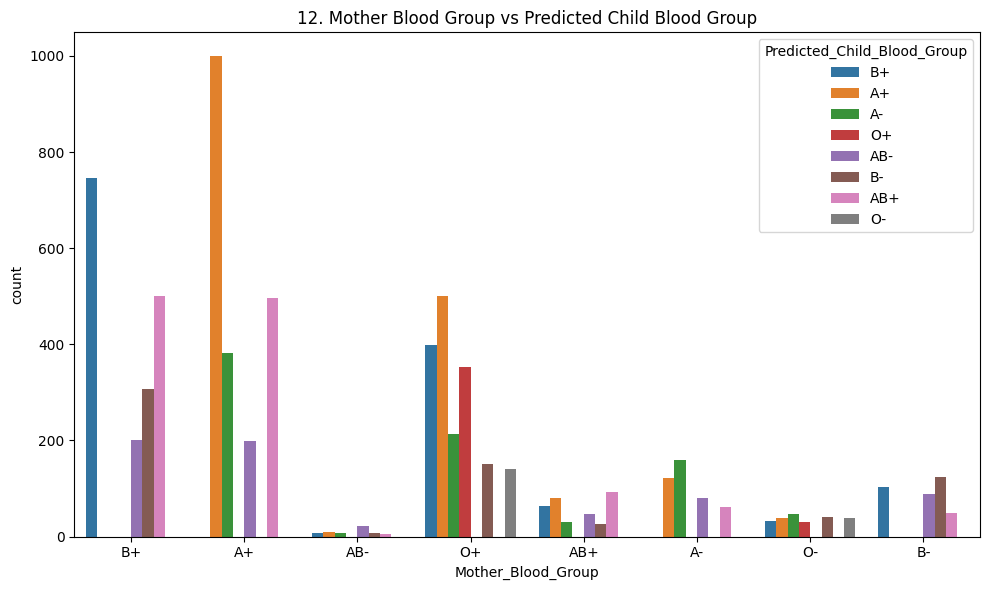

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Mother_Blood_Group', hue='Predicted_Child_Blood_Group')
plt.title(f'{plot_no}. Mother Blood Group vs Predicted Child Blood Group')
show_fig()
plot_no += 1

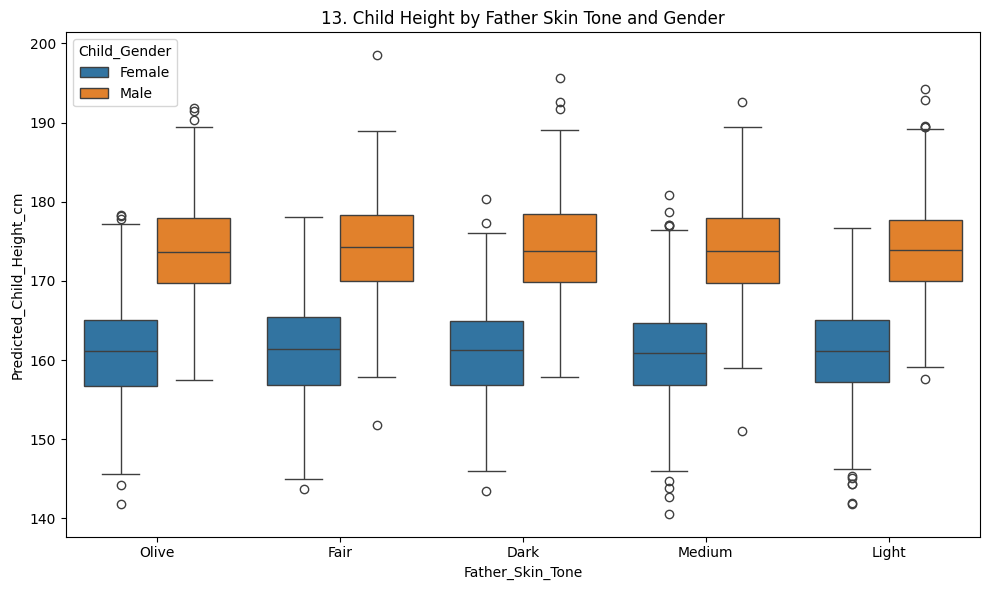

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Father_Skin_Tone', y='Predicted_Child_Height_cm', hue='Child_Gender')
plt.title(f'{plot_no}. Child Height by Father Skin Tone and Gender')
show_fig()
plot_no += 1

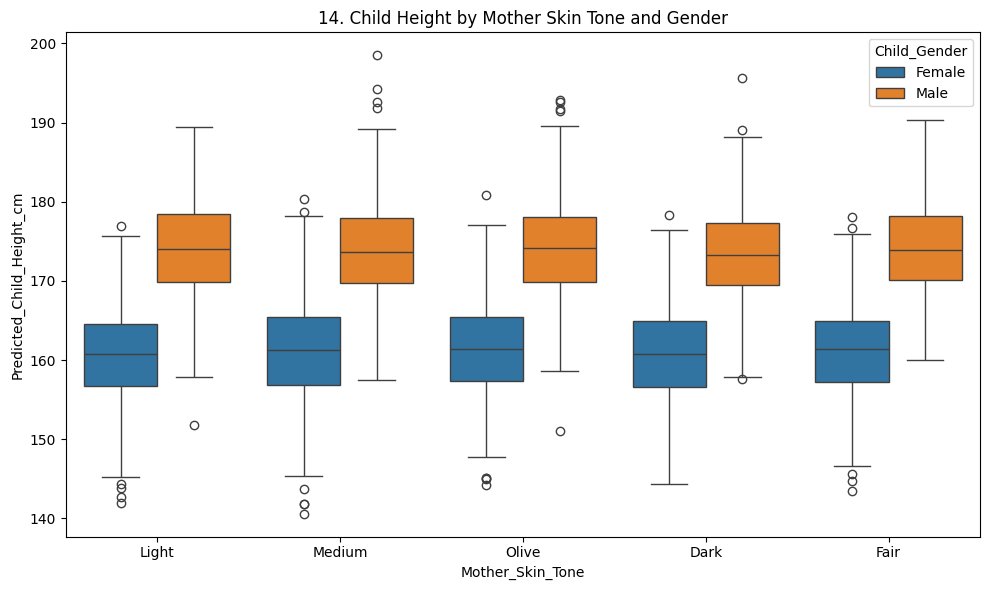

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Mother_Skin_Tone', y='Predicted_Child_Height_cm', hue='Child_Gender')
plt.title(f'{plot_no}. Child Height by Mother Skin Tone and Gender')
show_fig()
plot_no += 1

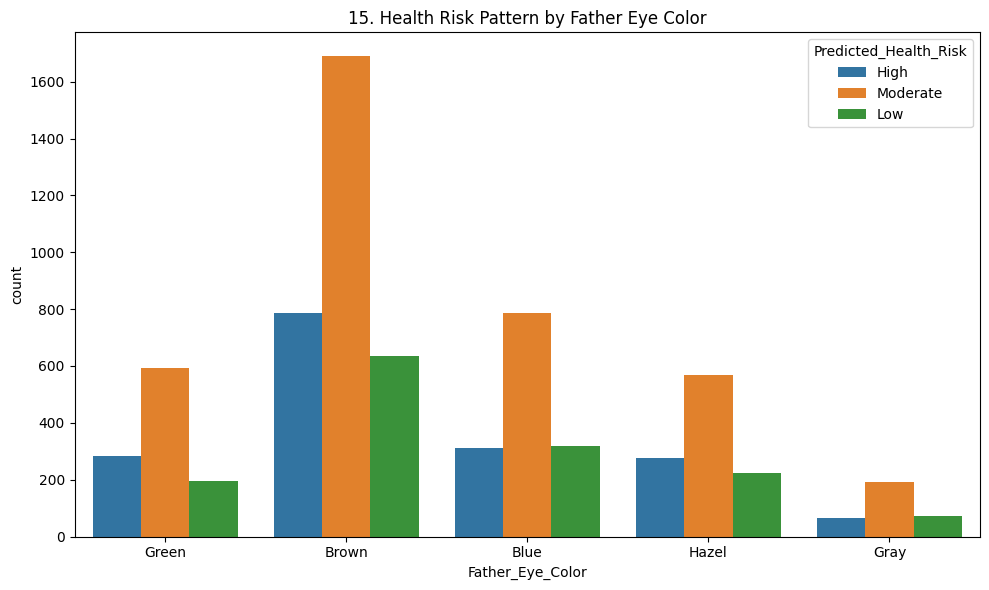

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Father_Eye_Color', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Health Risk Pattern by Father Eye Color')
show_fig()
plot_no += 1

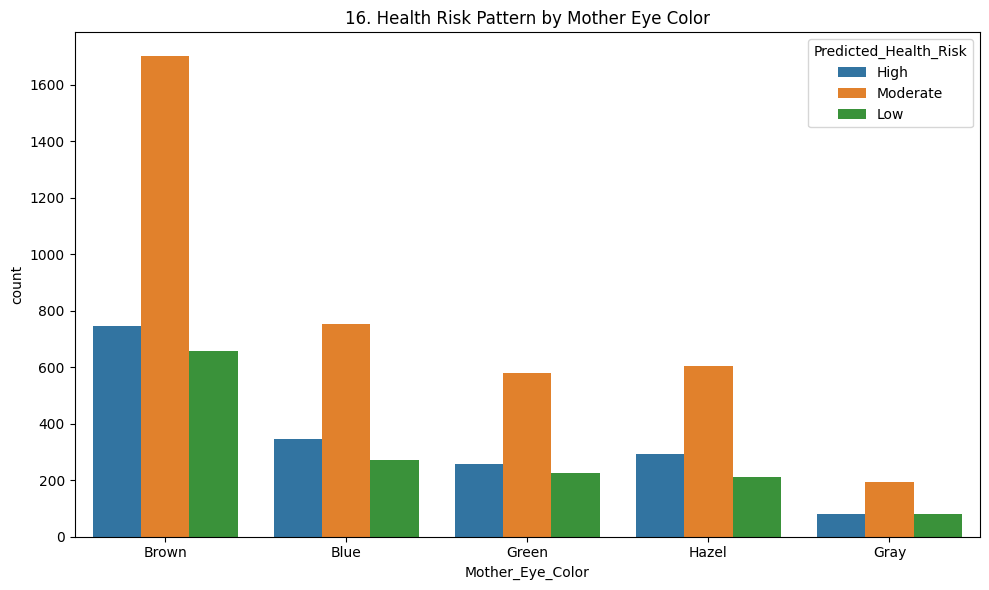

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Mother_Eye_Color', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Health Risk Pattern by Mother Eye Color')
show_fig()
plot_no += 1

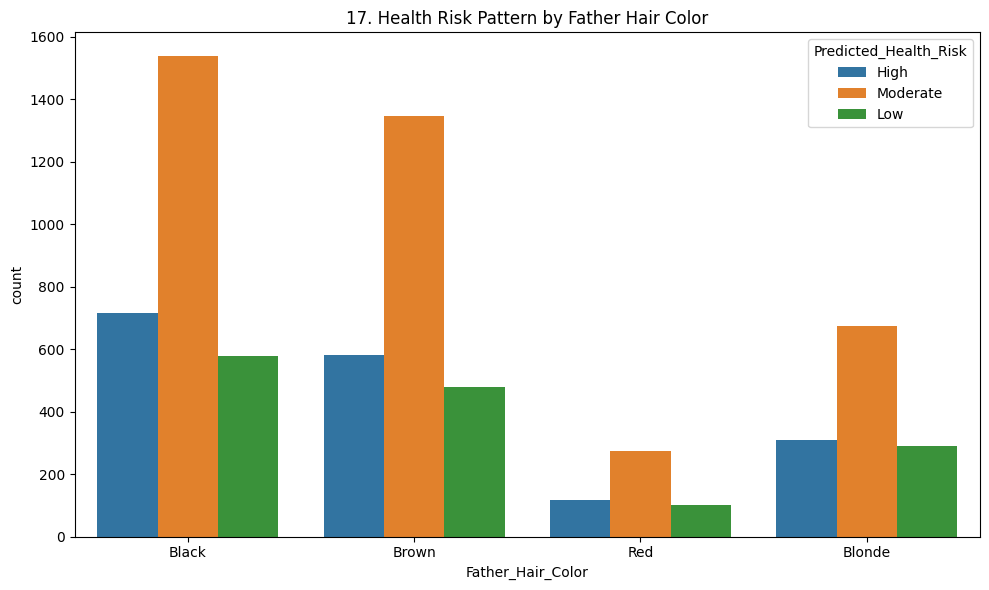

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Father_Hair_Color', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Health Risk Pattern by Father Hair Color')
show_fig()
plot_no += 1

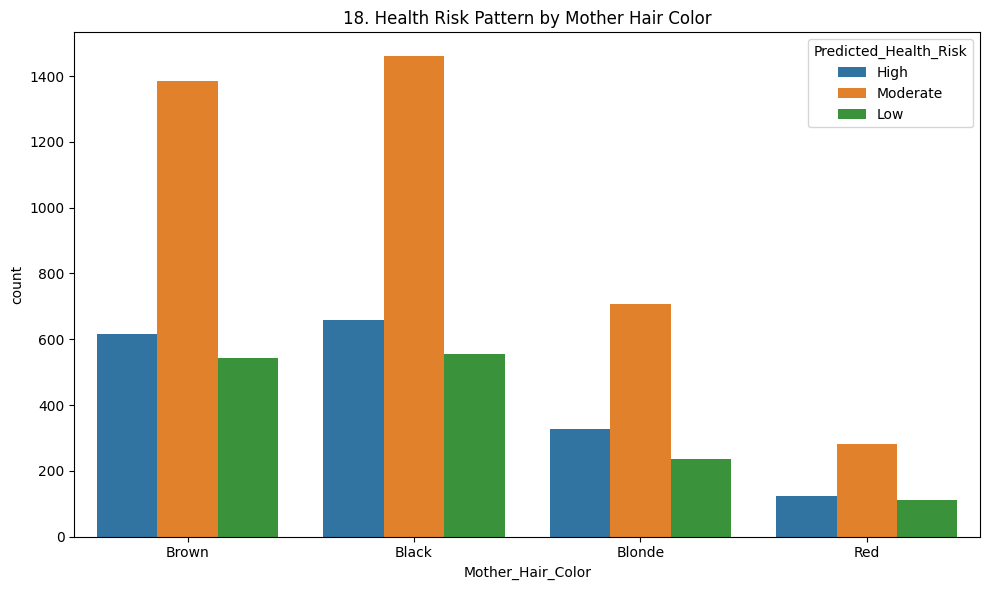

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Mother_Hair_Color', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Health Risk Pattern by Mother Hair Color')
show_fig()
plot_no += 1

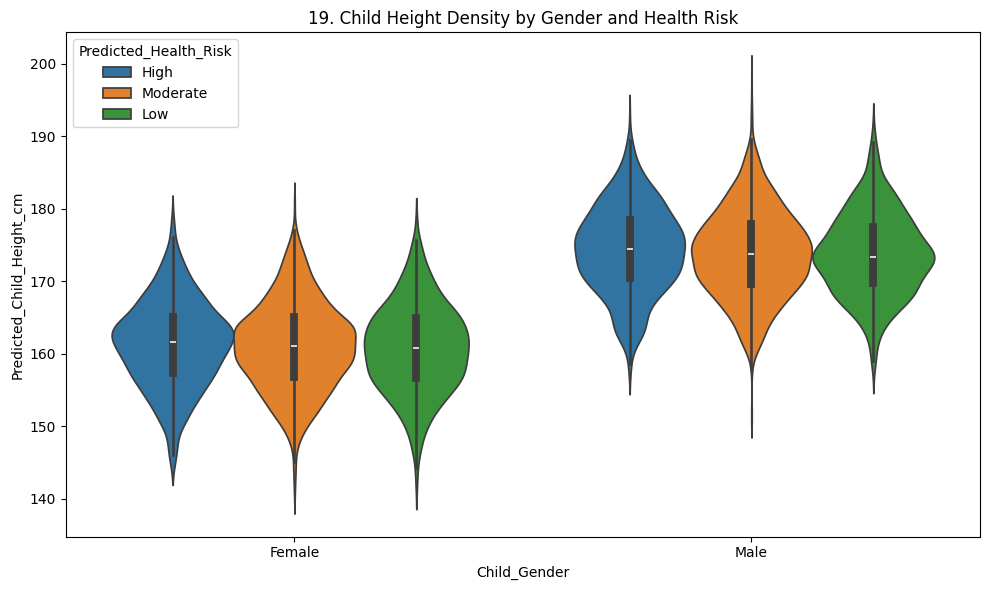

In [32]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Child_Gender', y='Predicted_Child_Height_cm', hue='Predicted_Health_Risk')
plt.title(f'{plot_no}. Child Height Density by Gender and Health Risk')
show_fig()
plot_no += 1

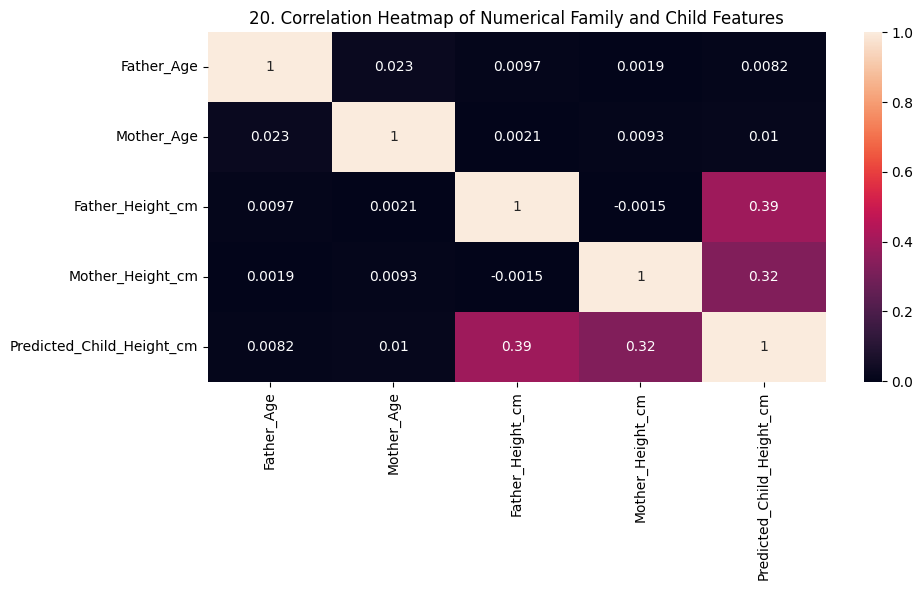

In [33]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Family and Child Features')
show_fig()
plot_no += 1

# Model Training

## Copy dataframe

In [34]:
data = df.copy()

## Remove ID column

In [35]:
data = data.drop(columns=['Family_ID'], errors='ignore')

## Select target column

In [36]:
target = 'Predicted_Child_Height_cm'

## Remove unrelated output columns

In [37]:
data = data.drop(columns=['Predicted_Health_Risk'], errors='ignore')

## Split input and output

In [38]:
X = data.drop(columns=[target])
y = data[target]

## Select numeric and categorical columns

In [39]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

## Preprocess numeric columns

In [40]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Preprocess categorical columns

In [41]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine preprocessing

In [42]:
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

## Create regression model

In [43]:
model = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.04,
    max_depth=3,
    random_state=42
)

## Create pipeline

In [44]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

## Split train and test data

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Train model

In [46]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Father_Age', 'Mother_Age', 'Father_Height_cm', 'Mother_Height_cm'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Father_Blood_Group', 'Mother_Blood_Group', 'Father_Eye_Color',
       'Mother_Eye_Color', 'Father_Hair_Color', 'Mother_Hair_Color',
       'Father_Skin_Tone', 'Mother_Skin_Tone', 'Child_Gender',
       'Predicted_Child_Blood_Group'],
      dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.04, n_estimators=600,
                                           random_state=42))])

## Predict test data

In [47]:
y_pred = pipeline.predict(X_test)

## Print model scores

In [48]:
print("R2 Accuracy Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Accuracy Score: 0.7693115638393079
MAE: 3.2175903893400246
RMSE: 4.089279338105456


## Create actual vs predicted dataframe

In [49]:
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}).sort_values(by='Actual')

## Plot actual vs predicted with perfect prediction line

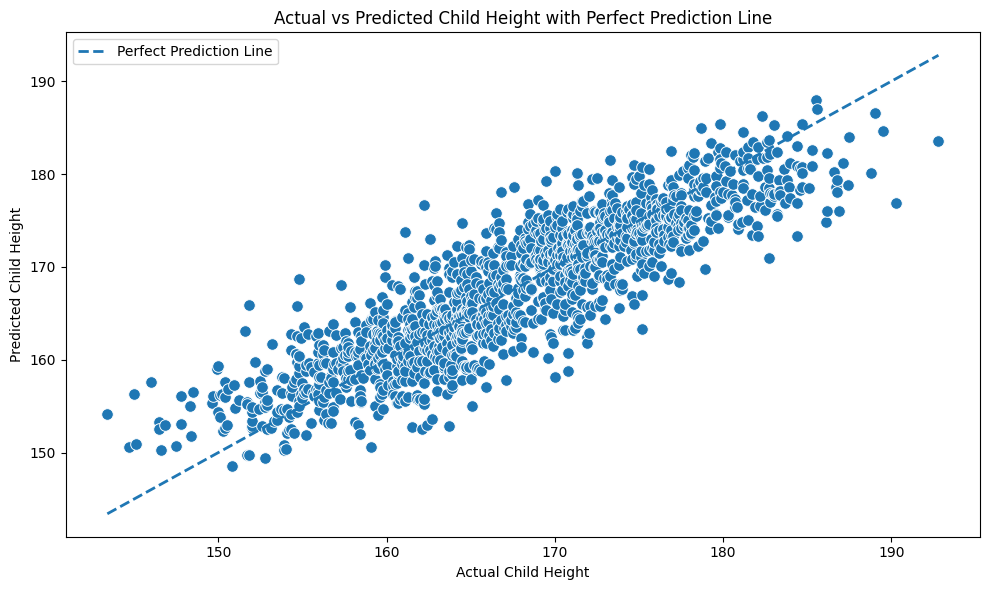

In [50]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=result, x='Actual', y='Predicted', s=70)
plt.plot(
    [result['Actual'].min(), result['Actual'].max()],
    [result['Actual'].min(), result['Actual'].max()],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction Line'
)
plt.xlabel("Actual Child Height")
plt.ylabel("Predicted Child Height")
plt.title("Actual vs Predicted Child Height with Perfect Prediction Line")
plt.legend()
plt.tight_layout()
plt.show()

## Plot actual and predicted line comparison

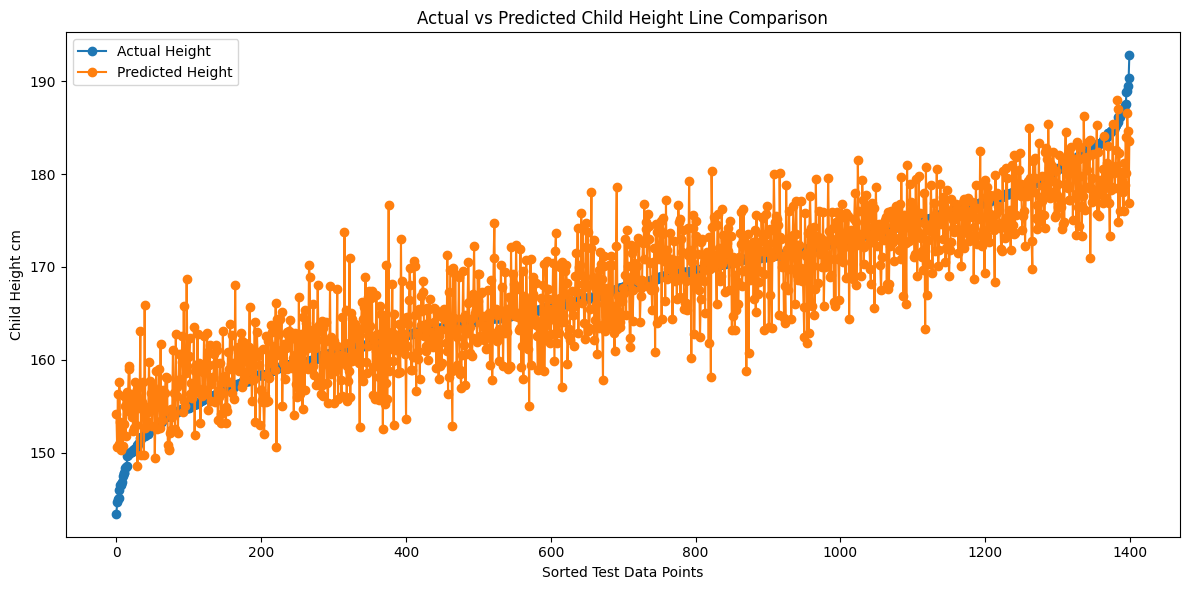

In [51]:
fig = plt.figure(figsize=(12,6))
plt.plot(result['Actual'].values, label='Actual Height', marker='o')
plt.plot(result['Predicted'].values, label='Predicted Height', marker='o')
plt.xlabel("Sorted Test Data Points")
plt.ylabel("Child Height cm")
plt.title("Actual vs Predicted Child Height Line Comparison")
plt.legend()
plt.tight_layout()
plt.show()